In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.datasets import make_classification
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns

from tsne_spectral import tsne_eigen, load_mnist, plot_embedding

## Next steps
Gradient descent
Stochastic gradient descent
Gradient flow itself (ODE)
- show time process, whether they shrink or blow up
- given p_ij's and starting data as well (randomly pick points about the origin)
    - how sensitive is the long term behavior to the initial condition
See the actual examples in the Paper
try to visualize how they converge using graphs
Interested in where it can fail (Where tSNE becomes a mess)
See how tSNE works with 100 equidistant points and bring them to R^2



- also pencil paper math

In [2]:
# Now we need to generate a dataset in high dimensions
def generate_data(n_samples=1000, n_features=50, n_classes=5): # 1000 data points, 50 dimensions, 5 clusters
    X, y = make_classification(n_samples=n_samples, n_features=n_features, n_informative=10, n_classes=n_classes, random_state=42)
    return X, y

## Section 2.1 — Synthetic Data and sklearn Baseline

In [3]:
# SciKit Learn has a built-in t-SNE function. We can use that here
def apply_tsne(X, n_components=2, perplexity=30.0, learning_rate=200.0):
    # Here we have input data in the form of X and then three arguments in the function, the number of components, the perplexity, and learning rate.
        # the number of components is the dimension we reduce it down to. 
        # The perplexity is whether we focus on local or global structures within the data. A perplexity of 5-10 means we are focussing on local structures 
            # and 50-100 is more on global structures.
        # The learning rate controls updating between the gradient descent.
    tsne = TSNE(n_components=n_components, perplexity=perplexity, learning_rate=learning_rate, random_state=42)
    X_embedded = tsne.fit_transform(X)
    return X_embedded

## Section 2.2 — Pedagogical From-Scratch Implementation

These naive nested-loop implementations mirror the algorithm description in
Section 2 of the thesis.  They are intentionally unoptimised for clarity.
**Do not use these for experiments** — use `tsne_spectral.tsne_eigen` instead.

In [4]:
# However, If we wanted to manually computw the t-SNE function we can do this too, it just takes more work

# First we will start with the P_ij's
def compute_high_dim_affinities(X, perplexity=30.0):
    # Computes the pairwise similarity probabilities in high-dimensional space
    (n, d) = X.shape
    distances = np.zeros((n, n)) # Euclidean distance
    for i in range(n):
        for j in range(i + 1, n):
            dist = np.sum((X[i] - X[j]) ** 2)
            distances[i, j] = dist
            distances[j, i] = dist  # Symmetric matrix
    P = np.exp(-distances / (2 * np.var(X)))
    P /= np.sum(P, axis=1, keepdims=True)
    return P

# Then we will calculate the q_ij's
def compute_low_dim_affinities(Y):
    # Computes the pairwise similarity probabilities in low-dimensional space using a t-distribution
    (n, d) = Y.shape
    distances = np.zeros((n, n)) # Euclidean distance
    for i in range(n):
        for j in range(i + 1, n):
            dist = np.sum((Y[i] - Y[j]) ** 2)
            distances[i, j] = dist
            distances[j, i] = dist  # Symmetric matrix
    Q = (1 + distances) ** -1
    np.fill_diagonal(Q, 0)
    Q /= np.sum(Q)
    return Q

# Then we will compute the gradient of the KL-divergence
def compute_gradient(P, Q, Y):
    PQ_diff = P - Q
    grad = np.zeros_like(Y) # array of 0's the same size as Y
    for i in range(Y.shape[0]):
        grad[i, :] = np.sum(np.expand_dims(PQ_diff[:, i], axis=1) * (Y[i, :] - Y), axis=0)
    return grad

# Then we will define our t-SNE function
def tsne(X, n_components=2, perplexity=30.0, learning_rate=200.0, n_iter=500): # Only additional argument is number of iterations, this is to help us converge
    np.random.seed(42)
    Y = np.random.randn(X.shape[0], n_components) * 0.01  # Initialize low-dim points
    P = compute_high_dim_affinities(X, perplexity)
    
    for i in range(n_iter):
        Q = compute_low_dim_affinities(Y)
        grad = compute_gradient(P, Q, Y)
        Y -= learning_rate * grad
        if i % 100 == 0:
            print(f"Iteration {i}/{n_iter} complete")
    
    return Y 

In [ ]:
# Use the production tsne_eigen instead of the pedagogical implementation above
Y_embedded = tsne_eigen(X, perplexity=30, T=500, eta=200, initialization_method="PCA")
plot_embedding(Y_embedded, y, title="Synthetic Data — PCA init (tsne_eigen)")

## Section 2.3 — Production Run with tsne_spectral

Replace the slow pedagogical implementation above with `tsne_eigen` for a
correctly-optimised embedding on the same synthetic data.

In [ ]:
# Then we can make the same plot with our manually coded t-SNE function
Y_embedded = tsne(X)
plot_results(Y_embedded, y)

Iteration 0/500 complete


KeyboardInterrupt: 

## Section 2.4 — MNIST with sklearn t-SNE

Load MNIST via `tsne_spectral.load_mnist` and compare sklearn's built-in t-SNE
with our manual implementation on a 10 000-sample subset.

In [ ]:
X_mnist, y_mnist = load_mnist(n_samples=10000, pca_components=30)
print(f"X shape: {X_mnist.shape}")

In [ ]:
tsne_sk = TSNE(n_components=2, learning_rate="auto", init="random",
               perplexity=30, random_state=1)
X_tsne = tsne_sk.fit_transform(X_mnist)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_mnist,
                      cmap="tab10", s=10, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label="Digit")
plt.title("sklearn t-SNE on MNIST (10 000 samples)")
plt.xlabel("Component 1"); plt.ylabel("Component 2")
plt.tight_layout(); plt.show()

In [3]:
# Libraries and data
import idx2numpy
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt



# train-labels.idx1-ubyte contains the digit labels for the 60,000 training images
train_labels = pd.DataFrame(idx2numpy.convert_from_file('archive/train-labels.idx1-ubyte'))

# train-images.idx3-ubyte contains the 60,000 grayscale images as 28×28 arrays
train_images = idx2numpy.convert_from_file('archive/train-images.idx3-ubyte')

# test-labels.idx1-ubyte contains the digit labels for the 10,000 test images
test_labels = pd.DataFrame(idx2numpy.convert_from_file('archive/t10k-labels.idx1-ubyte'))

# test-images.idx3-ubyte contains the 10,000 test images as 28×28 arrays
test_images = idx2numpy.convert_from_file('archive/t10k-images.idx3-ubyte')


# Each image is 28×28 = 784 pixels; reshape into (n_samples, 784)
flattened_train_images = train_images.reshape(train_images.shape[0], -1)
flattened_test_images  = test_images.reshape(test_images.shape[0], -1)


# We'll label the columns pixel0, pixel1, …, up to pixel783
column_names = [f'pixel{i}' for i in range(flattened_train_images.shape[1])]


# df_train_images: DataFrame of shape (60000, 784)
df_train_images = pd.DataFrame(flattened_train_images, columns=column_names)

# df_test_images: DataFrame of shape (10000, 784)
df_test_images  = pd.DataFrame(flattened_test_images,  columns=column_names)


# labels: DataFrame of shape (70000, 1)
labels = pd.concat([train_labels, test_labels], ignore_index=True)

# images: DataFrame of shape (70000, 784)
images = pd.concat([df_train_images, df_test_images], ignore_index=True)


# Make it clear that this single column holds the digit (0–9)
labels.columns = ['label']

Total variance explained by first 30 PCs: 48.66%


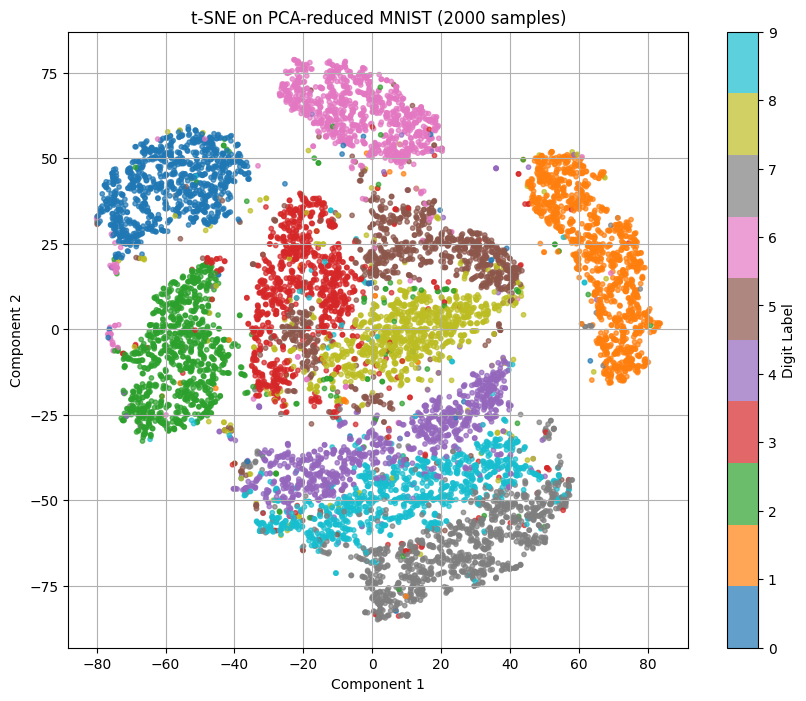

In [4]:
# Step 1: Sample 100 images (you can increase for more resolution)
sample_size = 10000
np.random.seed(1)
sample_indices = np.random.choice(images.shape[0], sample_size, replace=False)
sample_images = images.iloc[sample_indices]
sample_labels = labels.iloc[sample_indices]

# Step 2: Standardize the pixel values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(sample_images)

# Step 3: Apply PCA to reduce to 30 components
pca = PCA(n_components=30, random_state=1)
X_pca = pca.fit_transform(X_scaled)

# Optional: print explained variance
print(f"Total variance explained by first 30 PCs: {np.sum(pca.explained_variance_ratio_):.2%}")

# Step 4: Apply t-SNE to PCA-reduced data
tsne = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=30, random_state=1)
X_tsne = tsne.fit_transform(X_pca)

# Step 5: Plot with matplotlib
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=sample_labels['label'], cmap='tab10', s=10, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.title("t-SNE on PCA-reduced MNIST (2000 samples)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

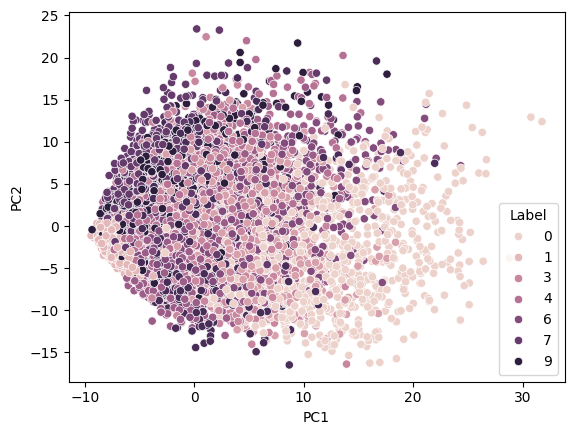

In [6]:
import seaborn as sns


pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Label': sample_labels.values.ravel()
})

sns.scatterplot(data = pca_df, x='PC1', y='PC2', hue='Label')
plt.show()